In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import Subset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

In [ ]:
# ---------------------------------------------------------
# 1. SETUP AND CONFIGURATION
# ---------------------------------------------------------
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available in Colab, otherwise fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

Using device: cpu



In [ ]:
# ---------------------------------------------------------
# 2. LOAD DATASET (MNIST)
# ---------------------------------------------------------
# Transform: Convert images to PyTorch tensors and normalize pixel values (-1 to 1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Downloading and loading MNIST dataset...")
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
full_test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(len(full_train_dataset))
print(len(full_test_dataset))

train_dataset = Subset(full_train_dataset, range(10000))
test_dataset = Subset(full_test_dataset, range(1000))

print(f"Truncated Training dataset size: {len(train_dataset)}")
print(f"Truncated Test dataset size: {len(test_dataset)}")

# DataLoaders batch the data and shuffle it for training
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

60000
10000
Truncated Training dataset size: 10000
Truncated Test dataset size: 1000


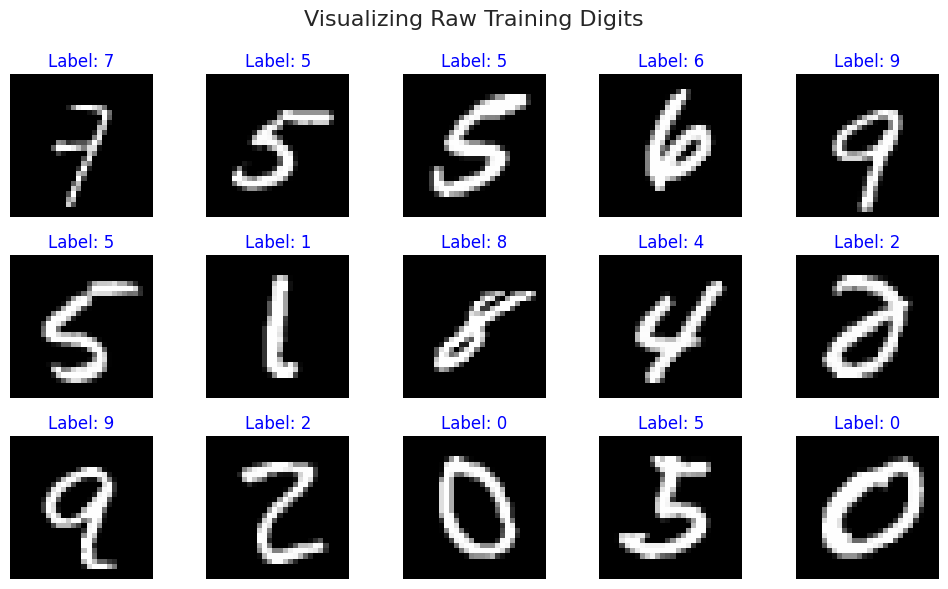

In [ ]:
# ---------------------------------------------------------
# 3. VISUALIZE RAW DATA
# ---------------------------------------------------------
def unnormalize(img):
    """Reverts normalization so images can be plotted properly"""
    return img / 2 + 0.5

# Get a single batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
fig.suptitle("Visualizing Raw Training Digits", fontsize=16)
for i, ax in enumerate(axes.flat):
    img = unnormalize(images[i]).squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}", color='blue')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 4. DEFINE THE NEURAL NETWORK
# ---------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolutional layers to extract visual features
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers to classify the features into 10 digits
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7) # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Starting Training...
Epoch [1/3] - Loss: 0.6339 - Test Accuracy: 92.20%
Epoch [2/3] - Loss: 0.1533 - Test Accuracy: 95.80%
Epoch [3/3] - Loss: 0.0986 - Test Accuracy: 96.50%


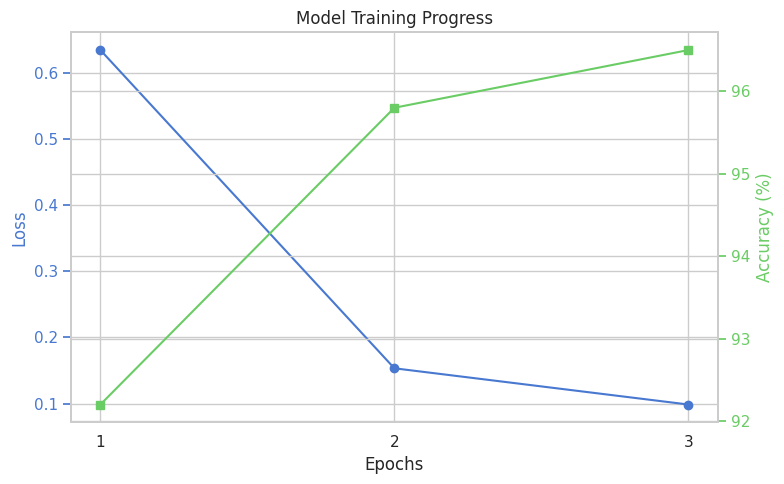

In [ ]:
# ---------------------------------------------------------
# 5. TRAIN THE MODEL & COLLECT METRICS
# ---------------------------------------------------------
epochs = 3
train_losses = []
test_accuracies = []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation step
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} - Test Accuracy: {accuracy:.2f}%")

# Plot Training Curves
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(range(1, epochs+1), train_losses, 'b-', marker='o', label='Train Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='b')
ax1.tick_params('y', colors='b')
ax1.set_xticks(range(1, epochs+1))

ax2 = ax1.twinx()
ax2.plot(range(1, epochs+1), test_accuracies, 'g-', marker='s', label='Test Accuracy')
ax2.set_ylabel('Accuracy (%)', color='g')
ax2.tick_params('y', colors='g')

plt.title("Model Training Progress")
fig.tight_layout()
plt.show()

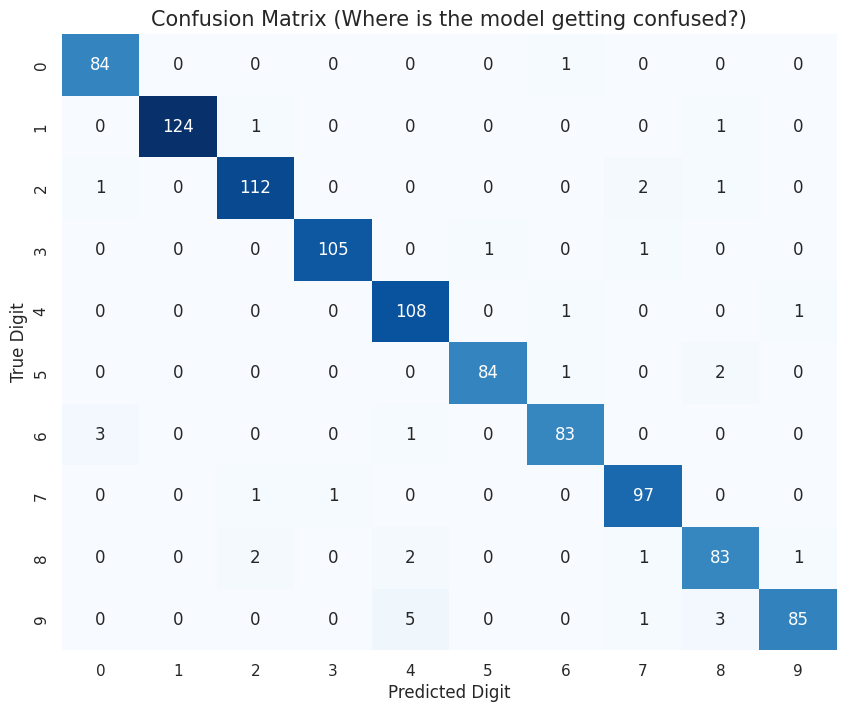

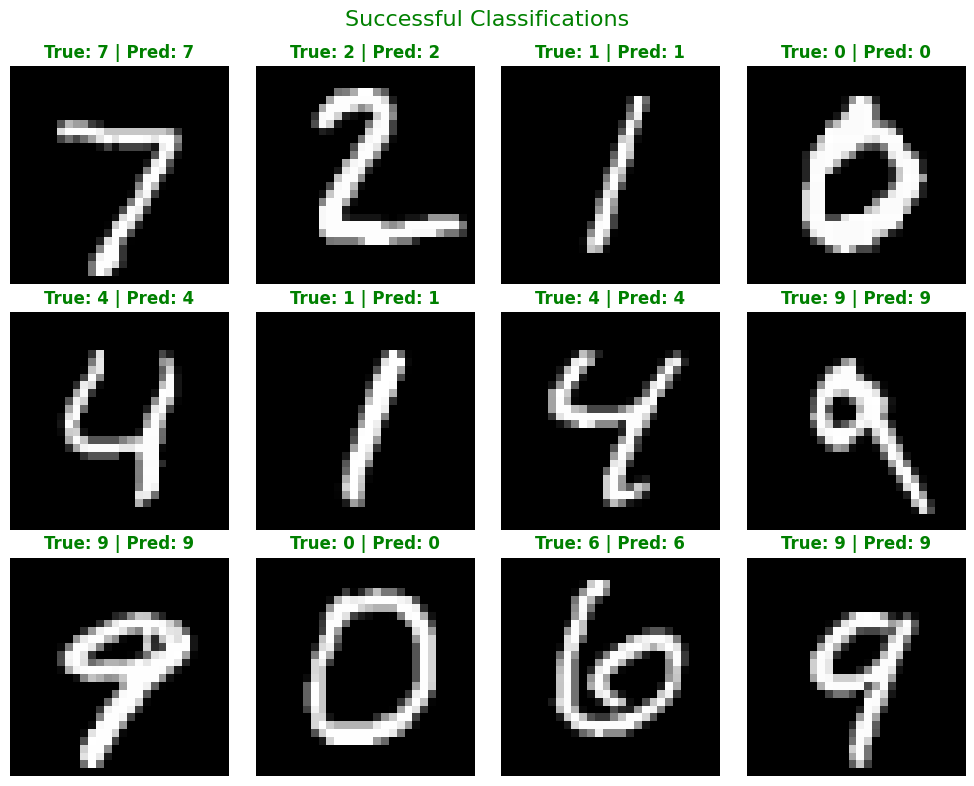

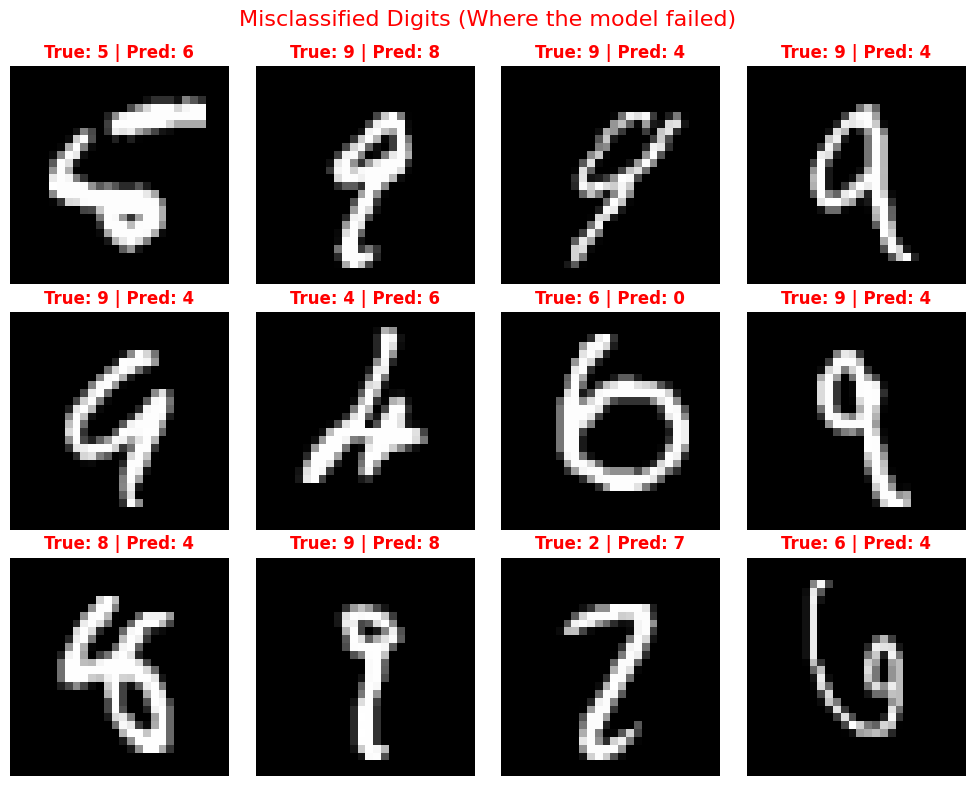


Final Test Accuracy: 96.50%
Total Misclassified Images: 35 out of 1000


In [ ]:
# ---------------------------------------------------------
# 6. EVALUATION & VISUALIZING RESULTS
# ---------------------------------------------------------
# Gather all predictions to build visuals
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Visual 1: Confusion Matrix Heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Digit', fontsize=12)
plt.ylabel('True Digit', fontsize=12)
plt.title('Confusion Matrix (Where is the model getting confused?)', fontsize=15)
plt.show()

# Find indices of correct and incorrect predictions
correct_idx = np.where(all_preds == all_labels)[0]
misclassified_idx = np.where(all_preds != all_labels)[0]

# Visual 2: Successful Predictions
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
fig.suptitle("Successful Classifications", fontsize=16, color='green')
for i, ax in enumerate(axes.flat):
    if i < len(correct_idx):
        idx = correct_idx[i]
        img, true_label = test_dataset[idx]
        pred_label = all_preds[idx]

        img = unnormalize(img).squeeze().numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {true_label} | Pred: {pred_label}", color='green', fontweight='bold')
        ax.axis('off')
plt.tight_layout()
plt.show()

# Visual 3: Misclassifications (Failure Analysis)
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
fig.suptitle("Misclassified Digits (Where the model failed)", fontsize=16, color='red')
for i, ax in enumerate(axes.flat):
    if i < len(misclassified_idx):
        idx = misclassified_idx[i]
        img, true_label = test_dataset[idx]
        pred_label = all_preds[idx]

        img = unnormalize(img).squeeze().numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {true_label} | Pred: {pred_label}", color='red', fontweight='bold')
        ax.axis('off')
plt.tight_layout()
plt.show()

print(f"\nFinal Test Accuracy: {test_accuracies[-1]:.2f}%")
print(f"Total Misclassified Images: {len(misclassified_idx)} out of {len(test_dataset)}")